In [13]:
using JuMP
using HiGHS
include("assignment_1_data.jl")

1×13 Matrix{Int64}:
 370  410  413  383  370  392  378  408  414  389  430  405  433

Benders decomposition

Question 2

In [14]:
#Model
model = Model(HiGHS.Optimizer)
I = 1:nS
J = 1:nC
S = 1:nSc

#Variables
@variable(model, y[i in I], Bin)
@variable(model, x[i in I] >= 0)
@variable(model, z[i in I, j in J, s in S] >= 0)
@variable(model, w[j in J, s in S] >= 0)

#Objective
@objective(model, Min,
    sum(F[i] * y[i] for i in I) +
    sum(C[i] * x[i] for i in I) +
    sum(P * (
        sum(T[i,j] * z[i,j,s] for i in I, j in J) +
        sum(u * w[j,s] for j in J)
    ) for s in S)
)

#Constraints
@constraint(model, [i in I],x[i] <= B[i] * y[i])
@constraint(model,sum(y[i] for i in I) <= n)
@constraint(model, [i in I, s in S], sum(z[i,j,s] for j in J) <= x[i])
@constraint(model, [j in J, s in S], sum(z[i,j,s] for i in I) + w[j,s] == D[j,s])


optimize!(model)
print(model)
println("Optimal objective value: ", objective_value(model))
println("\nSelected suppliers and reserved capacity:")

for i in I
    if value(y[i]) > 0.5
        println("Supplier ", i,
        " | capacity reserved = ", value(x[i]))
    end
end

Running HiGHS 1.8.0 (git hash: fcfb53414): Copyright (c) 2024 HiGHS under MIT licence terms
Coefficient ranges:
  Matrix [1e+00, 4e+02]
  Cost   [5e-02, 8e+01]
  Bound  [1e+00, 1e+00]
  RHS    [5e+00, 8e+01]
Presolving model
1374 rows, 15426 cols, 29999 nonzeros  0s
1374 rows, 15426 cols, 29999 nonzeros  0s

Solving MIP model with:
   1374 rows
   15426 cols (13 binary, 0 integer, 0 implied int., 15413 continuous)
   29999 nonzeros

        Nodes      |    B&B Tree     |            Objective Bounds              |  Dynamic Constraints |       Work      
     Proc. InQueue |  Leaves   Expl. | BestBound       BestSol              Gap |   Cuts   InLp Confl. | LpIters     Time

         0       0         0   0.00%   0               inf                  inf        0      0      0         0     0.1s
 R       0       0         0   0.00%   11715.85573     302142.8          96.12%        0      0      0      2507     0.3s
 C       0       0         0   0.00%   11744.313142    120115.05         9

Question 4

In [19]:
using MathOptInterface
const MOI = MathOptInterface

# Master problem
master = Model(HiGHS.Optimizer)
set_silent(master)

@variable(master, y[i in I], Bin)
@variable(master, x[i in I] >= 0)
@variable(master, θ >= 0)

@objective(master, Min,
    sum(F[i]*y[i] for i in I) +
    sum(C[i]*x[i] for i in I) +
    θ
)

@constraint(master, [i in I], x[i] <= B[i]*y[i])
@constraint(master, sum(y[i] for i in I) <= n)

function solve_master()
    optimize!(master)
    @assert termination_status(master) == MOI.OPTIMAL
    return value.(x), value.(y), value(θ), objective_value(master)
end

#Subproblem
function solve_subproblem(x_val, s)

    sub = Model(HiGHS.Optimizer)
    set_silent(sub)

    @variable(sub, α[j in J])
    @variable(sub, π[i in I] <= 0)

    @objective(sub, Max,
        sum(D[j,s]*α[j] for j in J) +
        sum(x_val[i]*π[i] for i in I)
    )

    @constraint(sub, [i in I, j in J], α[j] + π[i] <= T[i,j])
    @constraint(sub, [j in J], α[j] <= u)

    optimize!(sub)
    @assert termination_status(sub) == MOI.OPTIMAL

    return objective_value(sub), value.(α), value.(π)
end

# Main loop
let 
    UB = Inf
    LB = -Inf 
    ϵ = 1e-4
    iteration = 0

    while (UB - LB > ϵ)
        iteration += 1

        x_val, y_val, θ_val, master_obj = solve_master()
        LB = master_obj

        recourse_cost = 0.0
        cut_const = 0.0
        cut_coeff = zeros(length(I))

        for s in S
            val, α, π = solve_subproblem(x_val, s)

            recourse_cost += P * val
            cut_const += P * sum(D[j,s]*α[j] for j in J)

            for i in I
                cut_coeff[i] += P * π[i]
            end
        end

        UB = min(UB,
            sum(F[i]*y_val[i] for i in I) +
            sum(C[i]*x_val[i] for i in I) +
            recourse_cost
        )

        cut_value = cut_const + sum(cut_coeff[i]*x_val[i] for i in I)

        if θ_val < cut_value - 1e-6
            @constraint(master,
                θ >= cut_const + sum(cut_coeff[i]*x[i] for i in I)
            )
        end

        println("Iter ", iteration,
            " | LB = ", round(LB, digits=2),
            " | UB = ", round(UB, digits=2))
    end
end

Iter 1 | LB = 0.0 | UB = 929625.0
Iter 2 | LB = 5780.88 | UB = 23644.32
Iter 3 | LB = 6130.45 | UB = 13514.74
Iter 4 | LB = 6609.95 | UB = 12812.83
Iter 5 | LB = 9723.7 | UB = 12812.83
Iter 6 | LB = 10119.01 | UB = 12812.83
Iter 7 | LB = 10754.32 | UB = 12768.95
Iter 8 | LB = 11063.37 | UB = 12768.95
Iter 9 | LB = 11088.39 | UB = 12261.34
Iter 10 | LB = 11166.93 | UB = 12261.34
Iter 11 | LB = 11224.97 | UB = 12227.58
Iter 12 | LB = 11336.7 | UB = 12227.58
Iter 13 | LB = 11473.95 | UB = 12063.81
Iter 14 | LB = 11504.57 | UB = 12063.81
Iter 15 | LB = 11540.97 | UB = 12063.81
Iter 16 | LB = 11565.15 | UB = 12063.81
Iter 17 | LB = 11638.31 | UB = 12063.81
Iter 18 | LB = 11655.15 | UB = 11992.64
Iter 19 | LB = 11663.98 | UB = 11992.64
Iter 20 | LB = 11723.74 | UB = 11992.64
Iter 21 | LB = 11737.67 | UB = 11992.64
Iter 22 | LB = 11764.34 | UB = 11992.64
Iter 23 | LB = 11785.15 | UB = 11992.64
Iter 24 | LB = 11794.37 | UB = 11992.64
Iter 25 | LB = 11798.67 | UB = 11992.64
Iter 26 | LB = 11803

Question 5

In [21]:
# ---------------- MASTER ----------------
master = Model(HiGHS.Optimizer)
set_silent(master)

@variable(master, y[i in I], Bin)
@variable(master, x[i in I] >= 0)
@variable(master, θ >= 0)

@objective(master, Min,
    sum(F[i]*y[i] for i in I) +
    sum(C[i]*x[i] for i in I) +
    θ
)

@constraint(master, [i in I], x[i] <= B[i]*y[i])
@constraint(master, sum(y[i] for i in I) <= n)

function solve_master()
    optimize!(master)
    @assert termination_status(master) == MOI.OPTIMAL
    return value.(x), value.(y), value(θ), objective_value(master)
end

# ---------------- SUBPROBLEM (PRIMAL) ----------------
function solve_subproblem(x_val, s)
    sub = Model(HiGHS.Optimizer)
    set_silent(sub)

    @variable(sub, z[i in I, j in J] >= 0)

    @objective(sub, Min,
        sum(T[i,j]*z[i,j] for i in I, j in J)
    )

    @constraint(sub, [i in I],
        sum(z[i,j] for j in J) <= x_val[i]
    )

    @constraint(sub, [j in J],
        sum(z[i,j] for i in I) == D[j,s]
    )

    optimize!(sub)
    return termination_status(sub), sub
end

# ---------------- BENDERS LOOP ----------------

let
    UB = Inf
    LB = -Inf
    ϵ = 1e-4
    iteration = 0

    while (UB - LB > ϵ)

        iteration += 1

        x_val, y_val, θ_val, LB = solve_master()

        all_feasible = true
        recourse_cost = 0.0

        # store scenario costs (for optimality cut)
        Q = zeros(nSc)

        for s in S
            status, sub = solve_subproblem(x_val, s)

            if status == MOI.INFEASIBLE
                all_feasible = false
                @constraint(master,
                    sum(x[i] for i in I) >= sum(D[j,s] for j in J)
                )

                println("Iter $iteration: Feasibility cut added (scenario $s)")
                break

            elseif status == MOI.OPTIMAL
                Q[s] = objective_value(sub)
                recourse_cost += P * Q[s]
            end
        end

        if all_feasible
            UB = min(UB,
                sum(F[i]*y_val[i] for i in I) +
                sum(C[i]*x_val[i] for i in I) +
                recourse_cost
            )
            @constraint(master, θ >= recourse_cost)
        end

        println("Iter $iteration | LB = ",
                round(LB, digits=2),
                " | UB = ",
                UB == Inf ? "Inf" : string(round(UB, digits=2)))
    end

    println("Final LB = ", LB)
    println("Final UB = ", UB)
end

Iter 1: Feasibility cut added (scenario 1)
Iter 1 | LB = 0.0 | UB = Inf
Iter 2: Feasibility cut added (scenario 3)
Iter 2 | LB = 5681.0 | UB = Inf
Iter 3: Feasibility cut added (scenario 8)
Iter 3 | LB = 5981.0 | UB = Inf
Iter 4: Feasibility cut added (scenario 9)
Iter 4 | LB = 6021.0 | UB = Inf
Iter 5: Feasibility cut added (scenario 10)
Iter 5 | LB = 6126.0 | UB = Inf
Iter 6 | LB = 6241.0 | UB = 13609.55
Iter 7 | LB = 13609.55 | UB = 13609.55
Final LB = 13609.55
Final UB = 13609.55


Question 6

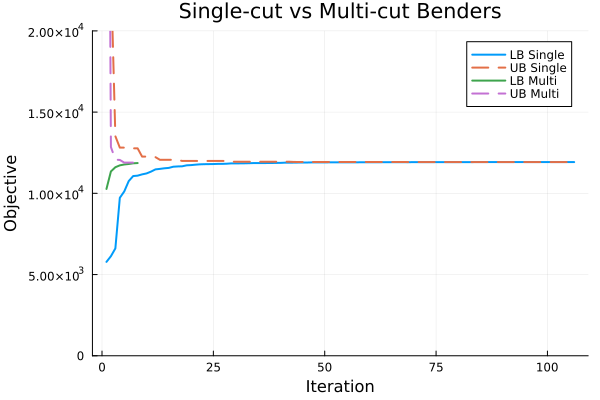

In [2]:
using JuMP
using HiGHS
using Plots
import MathOptInterface as MOI

include("assignment_1_data.jl")

I = 1:nS
J = 1:nC
S = 1:nSc
P = 1 / nSc
# Dual subproblem
function solve_subproblem(x_val, s)

    sub = Model(HiGHS.Optimizer)
    set_silent(sub)

    @variable(sub, π[i in I] <= 0)
    @variable(sub, α[j in J] <= u)  

    @objective(sub, Max,
        sum(x_val[i]*π[i] for i in I) +
        sum(D[j,s]*α[j] for j in J)
    )

    @constraint(sub, [i in I, j in J], π[i] + α[j] <= T[i,j])

    optimize!(sub)

    if termination_status(sub) == MOI.OPTIMAL
        π_val = collect(value.(π))
        α_val = collect(value.(α))

        a = π_val
        b = sum(D[j,s]*α_val[j] for j in J)

        return :optimal, a, b, objective_value(sub)

    else
        a = ones(length(I))
        b = -sum(D[j,s] for j in J)

        return :infeasible, a, b, 0.0
    end
end

# Single-cut Benders
function run_single_cut()

    master = Model(HiGHS.Optimizer)
    set_silent(master)

    @variable(master, y[i in I], Bin)
    @variable(master, x[i in I] >= 0)
    @variable(master, θ >= 0)

    @objective(master, Min,
        sum(F[i]*y[i] for i in I) +
        sum(C[i]*x[i] for i in I) +
        θ
    )

    @constraint(master, [i in I], x[i] <= B[i]*y[i])
    @constraint(master, sum(y[i] for i in I) <= n)

    LB_list, UB_list = Float64[], Float64[]

    function solve_master(a, b, is_opt)
        if is_opt
            @constraint(master, sum(a[i]*x[i] for i in I) + b <= θ)
        else
            @constraint(master, sum(a[i]*x[i] for i in I) + b <= 0)
        end

        optimize!(master)
        return value.(x), value.(y), value(θ), objective_value(master)
    end

    UB = Inf
    LB = -Inf
    ϵ = 1e-4

    x_val, y_val, θ_val, LB = solve_master(zeros(length(I)), 0.0, true)

    while (UB - LB > ϵ)

        total_a = zeros(length(I))
        total_b = 0.0
        recourse = 0.0
        feasible = true

        for s in S
            status, a, b, val = solve_subproblem(x_val, s)

            if status == :optimal
                total_a .+= P * a
                total_b += P * b
                recourse += P * val
            else
                x_val, y_val, θ_val, LB = solve_master(a, b, false)
                feasible = false
                break
            end
        end

        if feasible
            UB = min(UB,
                sum(F[i]*y_val[i] for i in I) +
                sum(C[i]*x_val[i] for i in I) +
                recourse
            )

            x_val, y_val, θ_val, LB = solve_master(total_a, total_b, true)
        end

        push!(LB_list, LB)
        push!(UB_list, UB)
    end

    return LB_list, UB_list
end


# Multi-cut Benders
function run_multi_cut()

    master = Model(HiGHS.Optimizer)
    set_silent(master)

    @variable(master, y[i in I], Bin)
    @variable(master, x[i in I] >= 0)
    @variable(master, θ[s in S] >= 0)

    @objective(master, Min,
        sum(F[i]*y[i] for i in I) +
        sum(C[i]*x[i] for i in I) +
        sum(P * θ[s] for s in S)
    )

    @constraint(master, [i in I], x[i] <= B[i]*y[i])
    @constraint(master, sum(y[i] for i in I) <= n)

    LB_list, UB_list = Float64[], Float64[]

    function solve_master(a, b, s, is_opt)
        if is_opt
            @constraint(master, sum(a[i]*x[i] for i in I) + b <= θ[s])
        else
            @constraint(master, sum(a[i]*x[i] for i in I) + b <= 0)
        end

        optimize!(master)
        return value.(x), value.(y), value.(θ), objective_value(master)
    end

    UB = Inf
    LB = -Inf
    ϵ = 1e-4

    x_val, y_val, θ_val, LB = solve_master(zeros(length(I)), 0.0, 1, true)

    while (UB - LB > ϵ)

        recourse = 0.0
        feasible = true

        for s in S
            status, a, b, val = solve_subproblem(x_val, s)

            if status == :optimal
                recourse += P * val
                x_val, y_val, θ_val, LB = solve_master(a, b, s, true)
            else
                x_val, y_val, θ_val, LB = solve_master(a, b, s, false)
                feasible = false
                break
            end
        end

        if feasible
            UB = min(UB,
                sum(F[i]*y_val[i] for i in I) +
                sum(C[i]*x_val[i] for i in I) +
                recourse
            )
        end

        push!(LB_list, LB)
        push!(UB_list, UB)
    end

    return LB_list, UB_list
end

# Plot

LB_single, UB_single = run_single_cut()
LB_multi, UB_multi = run_multi_cut()

plot(LB_single, label="LB Single", lw=2)
plot!(UB_single, label="UB Single", lw=2, linestyle=:dash)

plot!(LB_multi, label="LB Multi", lw=2)
plot!(UB_multi, label="UB Multi", lw=2, linestyle=:dash)

xlabel!("Iteration")
ylabel!("Objective")
title!("Single-cut vs Multi-cut Benders")
ylims!(0, 20000)

Progressive Hedging

Question 3

Set parameter Username
Set parameter LicenseID to value 2793718
Academic license - for non-commercial use only - expires 2027-03-17

=== Progressive Hedging Results (ρ = 8.0) ===
Iterations to convergence: 57
Final residual: 5.87e-03

Final capacity reservation x̄:
  Supplier  1: x̄ =    55.31
  Supplier  2: x̄ =     0.00
  Supplier  3: x̄ =     0.00
  Supplier  4: x̄ =   117.01
  Supplier  5: x̄ =   311.18
  Supplier  6: x̄ =   140.99
  Supplier  7: x̄ =     0.00
  Supplier  8: x̄ =    81.77
  Supplier  9: x̄ =    75.61
  Supplier 10: x̄ =     0.00
  Supplier 11: x̄ =   430.00
  Supplier 12: x̄ =   310.05
  Supplier 13: x̄ =   433.00


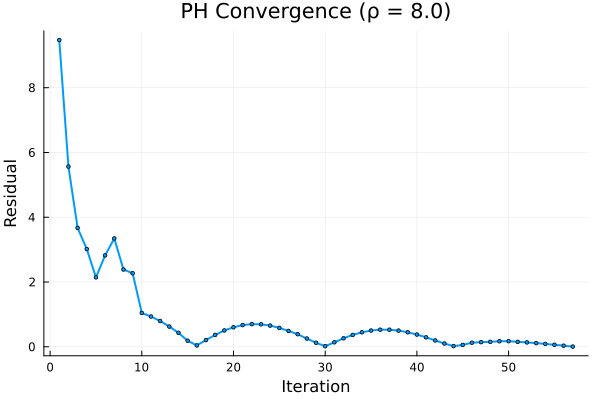


Objective value: 11458.63


In [4]:
using JuMP
using Gurobi
using Printf
using Plots

const GRB_ENV = Gurobi.Env()
Gurobi_constructor = () -> Gurobi.Optimizer(GRB_ENV)
include("assignment_1_data.jl")

n_suppliers = nS
n_clients   = nC
n_scenarios = nSc

I = 1:n_suppliers
J = 1:n_clients
S = 1:n_scenarios
assignment_cost = T
supplier_capacity = [370, 410, 413, 383, 370, 392, 378, 408, 414, 389, 430, 405, 433]
reservation_cost  = [4, 9, 9, 8, 5, 5, 9, 7, 4, 8, 2, 5, 1]

# Scenario probabilities 
prob = fill(1.0 / n_scenarios, n_scenarios)


#Scenario subproblem
function solve_scenario_subproblem(s::Int;
    λ = zeros(n_suppliers),
    x_bar = zeros(n_suppliers),
    ρ = 0.0)

    model = Model(Gurobi_constructor)
    set_silent(model)

    @variable(model, 0 <= x[i in I] <= supplier_capacity[i])
    @variable(model, q[i in I, j in J] >= 0)
    @variable(model, z[j in J] >= 0)

    @constraint(model, cap[i in I], sum(q[i, j] for j in J) <= x[i])
    @constraint(model, dem[j in J], sum(q[i, j] for i in I) + z[j] == D[j, s])

    @objective(model, Min,
        sum(reservation_cost[i] * x[i] for i in I) +
        sum(assignment_cost[i, j] * q[i, j] for i in I, j in J) +
        sum(u * z[j] for j in J) +
        sum(λ[i] * (x[i] - x_bar[i]) for i in I) +
        (ρ / 2) * sum((x[i] - x_bar[i])^2 for i in I)
    )

    optimize!(model)

    x_vals = [value(x[i]) for i in I]
    q_vals = [value(q[i, j]) for i in I, j in J]
    z_vals = [value(z[j]) for j in J]

    return x_vals, q_vals, z_vals, objective_value(model)
end

#Evaluates objective value
function evaluate_solution(x_fixed)
    reservation_cost_total = sum(reservation_cost[i] * x_fixed[i] for i in I)
    expected_recourse = 0.0
    for s in S
        model = Model(Gurobi_constructor)
        set_silent(model)

        @variable(model, q[i in I, j in J] >= 0)
        @variable(model, z[j in J] >= 0)

        @constraint(model, cap[i in I], sum(q[i, j] for j in J) <= x_fixed[i])
        @constraint(model, dem[j in J], sum(q[i, j] for i in I) + z[j] == D[j, s])

        @objective(model, Min,
            sum(assignment_cost[i, j] * q[i, j] for i in I, j in J) +
            sum(u * z[j] for j in J))

        optimize!(model)
        expected_recourse += prob[s] * objective_value(model)
    end
    return reservation_cost_total + expected_recourse
end


#
function main()

x_sol = zeros(n_suppliers, n_scenarios)

# Iteration 0, solves each scenario independently
for s in S
    xs, _, _, _ = solve_scenario_subproblem(s)
    x_sol[:, s] = xs
end

x_bar = [sum(prob[s] * x_sol[i, s] for s in S) for i in I]


# PH loop
ρ = 8.0
max_iter = 200
tol = 1e-2

λ = zeros(n_suppliers, n_scenarios)

residual_history = Float64[]
converged_iter = max_iter

for k in 1:max_iter

    #x-update: solve per-scenario subproblems
    for s in S
        xs, _, _, _ = solve_scenario_subproblem(s;
            λ = λ[:, s], x_bar = x_bar, ρ = ρ)
        x_sol[:, s] = xs
    end

    #z-update: consensus
    x_bar = [sum(prob[s] * x_sol[i, s] for s in S) for i in I]

    #λ-update
    for s in S, i in I
        λ[i, s] += ρ * (x_sol[i, s] - x_bar[i])
    end

    residual = sqrt(sum(prob[s] * sum((x_sol[i, s] - x_bar[i])^2 for i in I) for s in S))
    push!(residual_history, residual)

    if residual < tol
        converged_iter = k
        break
    end
end


# Results
# 1. Number of iterations
@printf("\n=== Progressive Hedging Results (ρ = %.1f) ===\n", ρ)
@printf("Iterations to convergence: %d\n", converged_iter)
@printf("Final residual: %.2e\n\n", residual_history[end])

# 2. Final solution (true objective value)
println("Final capacity reservation x̄:")
for i in I
    @printf("  Supplier %2d: x̄ = %8.2f\n", i, x_bar[i])
end

total_expected_cost = evaluate_solution(x_bar)
@printf("\nObjective value: %.2f\n", total_expected_cost)


# 3. Convergence plot
p = plot(1:length(residual_history), residual_history,
    xlabel = "Iteration", ylabel = "Residual",
    title = "PH Convergence (ρ = $ρ)",
    legend = false, lw = 2, marker = :circle, markersize = 2)
savefig(p, joinpath(@__DIR__, "ph_convergence.png"))
display(p)


end # main

main()